# Algoritmo Genético N-Queens (alternativa 03)

In [1]:
%pip install numpy matplotlib

import random
import time
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [2]:
def gerar_populacao(m, n):
    matriz = np.zeros((m, n), dtype=int)
    for i in range(m):
        for j in range(n):
            matriz[i][j] = random.randint(1, n)
    return matriz


def verifica_conflitos(matriz):
    conflitos = np.zeros((matriz.shape[0], 1), dtype=int)

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            for k in range(j + 1, matriz.shape[1]):

                # conflito na mesma linha
                if matriz[i][k] == matriz[i][j]:
                    conflitos[i] += 1

                # conflito na diagonal
                if abs(j - k) == abs(matriz[i][j] - matriz[i][k]):
                    conflitos[i] += 1

    return conflitos, conflitos.sum()


def seleciona_pai_binario(conflitos):
    pai_01_index = random.randint(0, len(conflitos) - 1)
    pai_02_index = random.randint(0, len(conflitos) - 1)

    while pai_02_index == pai_01_index:
        pai_02_index = random.randint(0, len(conflitos) - 1)

    if conflitos[pai_01_index][0] < conflitos[pai_02_index][0]:
        return pai_01_index
    else:
        return pai_02_index


def cruzamento(pai_01, pai_02, ponto_corte):
    filho_01 = np.concatenate((pai_01[:ponto_corte], pai_02[ponto_corte:]))
    filho_02 = np.concatenate((pai_02[:ponto_corte], pai_01[ponto_corte:]))
    return filho_01, filho_02


def mutacao(filho, taxa, n):
    if random.random() < taxa:
        posicao = random.randint(0, len(filho) - 1)
        novo_valor = random.randint(1, n)

        while novo_valor == filho[posicao]:
            novo_valor = random.randint(1, n)

        filho[posicao] = novo_valor

    return filho

def gerar_filhos(matriz_atual, conflitos, m, n, taxa_mutacao):
    filhos = []

    while len(filhos) < m:
        pai_01_index = seleciona_pai_binario(conflitos)
        pai_02_index = seleciona_pai_binario(conflitos)

        pai_01 = matriz_atual[pai_01_index]
        pai_02 = matriz_atual[pai_02_index]

        ponto_corte = random.randint(1, n - 1)
        filho_01, filho_02 = cruzamento(pai_01, pai_02, ponto_corte)

        filho_01 = mutacao(filho_01, taxa_mutacao, n)
        filho_02 = mutacao(filho_02, taxa_mutacao, n)

        filhos.append(filho_01)
        if len(filhos) < m:
            filhos.append(filho_02)

    return np.array(filhos)

def atualizacao_sem_elitismo(filhos):
    return filhos.copy()

def atualizacao_com_elitismo(matriz_atual, filhos):
    conflitos_pais, _ = verifica_conflitos(matriz_atual)
    conflitos_filhos, _ = verifica_conflitos(filhos)

    melhor_pai_idx = np.argmin(conflitos_pais) # pega o índice do indivíduo de menor conflito
    pior_filho_idx = np.argmax(conflitos_filhos) # pega o índice do indivíduo de maior conflito

    nova_populacao = filhos.copy()
    nova_populacao[pior_filho_idx] = matriz_atual[melhor_pai_idx].copy()

    return nova_populacao

def atualizacao_k_melhores_pais(matriz_atual, filhos, m, k):
    conflitos_pais, _ = verifica_conflitos(matriz_atual)

    indices_ordenados_pais = np.argsort(conflitos_pais.flatten()) # ordena os índices dos pais com base nos conflitos
    melhores_pais = matriz_atual[indices_ordenados_pais[:k]]

    quantidade_filhos_necessaria = m - k
    filhos_utilizados = filhos[:quantidade_filhos_necessaria]

    nova_populacao = np.vstack((melhores_pais, filhos_utilizados))
    return nova_populacao

def atualizacao_k_melhores_filhos(matriz_atual, filhos, m, k):
    conflitos_filhos, _ = verifica_conflitos(filhos)
    conflitos_pais, _ = verifica_conflitos(matriz_atual)

    indices_ordenados_filhos = np.argsort(conflitos_filhos.flatten())
    melhores_filhos = filhos[indices_ordenados_filhos[:k]]

    quantidade_pais_necessaria = m - k
    indices_ordenados_pais = np.argsort(conflitos_pais.flatten())
    melhores_pais = matriz_atual[indices_ordenados_pais[:quantidade_pais_necessaria]]

    nova_populacao = np.vstack((melhores_pais, melhores_filhos))
    return nova_populacao

def atualizacao_pais_filhos_melhores(matriz_atual, filhos, m):
    populacao_combinada = np.vstack((matriz_atual, filhos))
    conflitos_combinados, _ = verifica_conflitos(populacao_combinada)

    indices_ordenados = np.argsort(conflitos_combinados.flatten())
    melhores_indices = indices_ordenados[:m]

    nova_populacao = populacao_combinada[melhores_indices]
    return nova_populacao

def atualizacao_pais_filhos_aleatoria(matriz_atual, filhos, m):
    populacao_combinada = np.vstack((matriz_atual, filhos))
    indices_escolhidos = np.random.choice(populacao_combinada.shape[0], size=m, replace=False)

    nova_populacao = populacao_combinada[indices_escolhidos]
    return nova_populacao

In [3]:
def executar_alternativa3(m, n, geracoes, taxa_mutacao, metodo, k):
    inicio = time.time()

    matriz_inicial = gerar_populacao(m, n)
    conflitos_iniciais, qtdd_conflitos_inicial = verifica_conflitos(matriz_inicial)

    matriz_atual = matriz_inicial.copy()

    historico_media = []
    historico_melhor = [] # histórico do melhor conflito de cada geração

    melhor_conflito_global = 999999
    melhor_individuo_global = None
    melhor_geracao_global = -1

    geracao_convergencia = geracoes

    for geracao in range(geracoes):
        conflitos, conflitos_total = verifica_conflitos(matriz_atual)
        media_conflitos = conflitos_total / m
        melhor_conflito_geracao = int(conflitos.min())
        melhor_indice_geracao = int(np.argmin(conflitos)) # pega o índice do indivíduo de menor conflito

        historico_media.append(media_conflitos)
        historico_melhor.append(melhor_conflito_geracao)

        if melhor_conflito_geracao < melhor_conflito_global:
            melhor_conflito_global = melhor_conflito_geracao
            melhor_individuo_global = matriz_atual[melhor_indice_geracao].copy()
            melhor_geracao_global = geracao + 1

        filhos = gerar_filhos(matriz_atual, conflitos, m, n, taxa_mutacao)

        if metodo == "sem_elitismo":
            matriz_atual = atualizacao_sem_elitismo(filhos)

        elif metodo == "com_elitismo":
            matriz_atual = atualizacao_com_elitismo(matriz_atual, filhos)

        elif metodo == "k_melhores_pais":
            matriz_atual = atualizacao_k_melhores_pais(matriz_atual, filhos, m, k)

        elif metodo == "k_melhores_filhos":
            matriz_atual = atualizacao_k_melhores_filhos(matriz_atual, filhos, m, k)

        elif metodo == "pais_filhos_melhores":
            matriz_atual = atualizacao_pais_filhos_melhores(matriz_atual, filhos, m)

        elif metodo == "pais_filhos_aleatoria":
            matriz_atual = atualizacao_pais_filhos_aleatoria(matriz_atual, filhos, m)

        else:
            raise ValueError("Método inválido.")

    conflitos_finais, qtdd_conflitos_final = verifica_conflitos(matriz_atual)
    tempo_execucao = time.time() - inicio

    return {
        "qtdd_conflitos_inicial": int(qtdd_conflitos_inicial),
        "qtdd_conflitos_final": int(qtdd_conflitos_final),
        "historico_media": historico_media,
        "historico_melhor": historico_melhor,
        "melhor_conflito_global": int(melhor_conflito_global),
        "melhor_individuo_global": melhor_individuo_global,
        "melhor_geracao_global": melhor_geracao_global,
        "geracao_convergencia": geracao_convergencia,
        "tempo_execucao": tempo_execucao
    }

## Execução para 50 indivíduos, 8 rainhas, 50 gerações


Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 8
Tempo médio de execução: 0.0546 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 1.07
Taxa de sucesso: 13.33%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 8
Tempo médio de execução: 0.1526 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 0.70
Taxa de sucesso: 40.00%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 8
Tempo médio de execução: 0.1040 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 1.03
Taxa de sucesso: 23.33%


Executando método: Inserir k melhores filhos
===== TABELA RESUMO =================================
Método: Inserir 

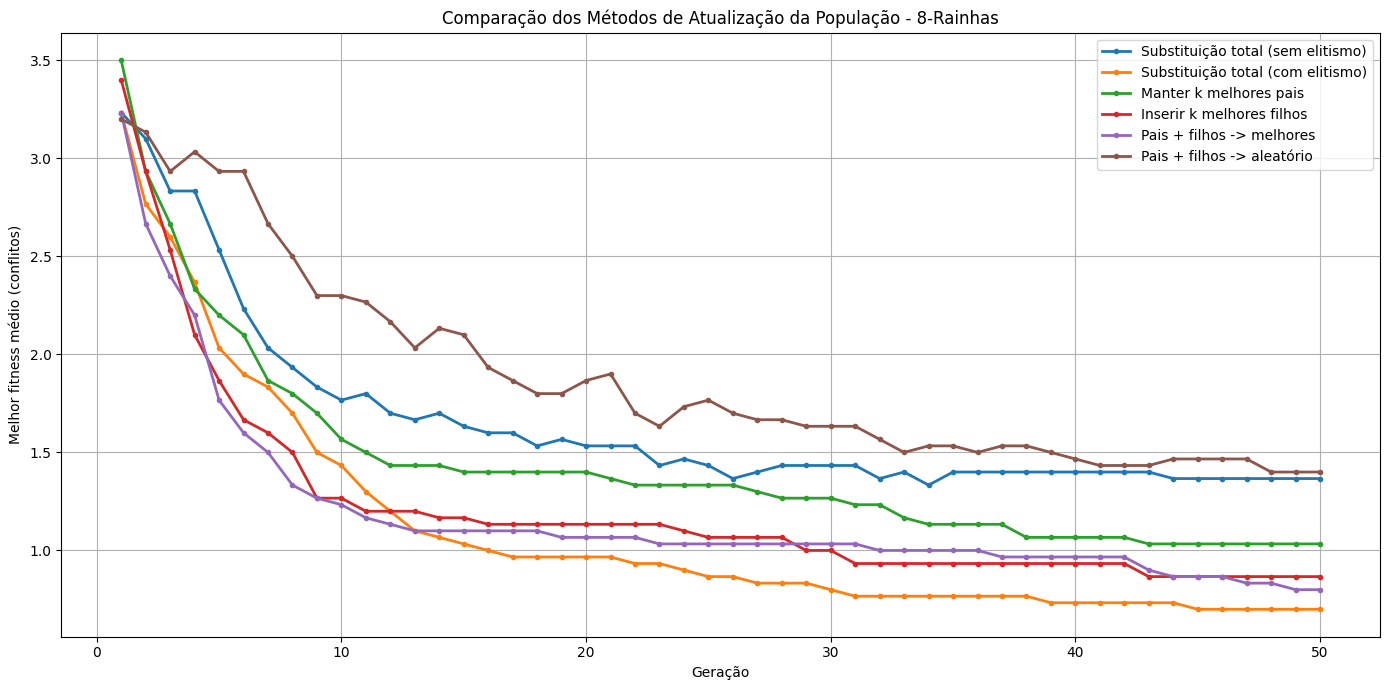

In [4]:
num_execucoes = 30
metodos = [
    "sem_elitismo",
    "com_elitismo",
    "k_melhores_pais",
    "k_melhores_filhos",
    "pais_filhos_melhores",
    "pais_filhos_aleatoria"
]

nomes_metodos = {
    "sem_elitismo": "Substituição total (sem elitismo)",
    "com_elitismo": "Substituição total (com elitismo)",
    "k_melhores_pais": "Manter k melhores pais",
    "k_melhores_filhos": "Inserir k melhores filhos",
    "pais_filhos_melhores": "Pais + filhos -> melhores",
    "pais_filhos_aleatoria": "Pais + filhos -> aleatório"
}

n = 8
m = 50
geracoes = 50
taxa_mutacao = 0.05
k = 15

# guarda resultados por método
resultados_por_metodo = {}

for metodo_escolhido in metodos:
    print(f"\nExecutando método: {nomes_metodos[metodo_escolhido]}")
    
    resultados_execucoes = []

    for execucao in range(num_execucoes):
        resultado = executar_alternativa3(
            m=m,
            n=n,
            geracoes=geracoes,
            taxa_mutacao=taxa_mutacao,
            metodo=metodo_escolhido,
            k=k
        )
        resultados_execucoes.append(resultado)

    tempos = [r["tempo_execucao"] for r in resultados_execucoes]
    geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
    melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]
    sucessos = [1 if r["melhor_conflito_global"] == 0 else 0 for r in resultados_execucoes]

    tempo_medio = np.mean(tempos)
    geracoes_medias = np.mean(geracoes_conv)
    melhor_fitness_medio = np.mean(melhores_finais)
    taxa_sucesso = np.mean(sucessos) * 100

    print("===== TABELA RESUMO =================================")
    print(f"Método: {nomes_metodos[metodo_escolhido]}")
    print(f"n = {n}")
    print(f"Tempo médio de execução: {tempo_medio:.4f} s")
    print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
    print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")
    print(f"Taxa de sucesso: {taxa_sucesso:.2f}%")
    print("=====================================================\n")

    historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
    historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

    media_historico_media = np.mean(historicos_media, axis=0)
    media_historico_melhor = np.mean(historicos_melhor, axis=0)

    resultados_por_metodo[metodo_escolhido] = {
        "tempo_medio": tempo_medio,
        "geracoes_medias": geracoes_medias,
        "melhor_fitness_medio": melhor_fitness_medio,
        "taxa_sucesso": taxa_sucesso,
        "media_historico_media": media_historico_media,
        "media_historico_melhor": media_historico_melhor
    }

print("\nTodas as execuções concluídas.")

# ---------- GRÁFICO --------------------------------------------------

plt.figure(figsize=(14, 7))

for metodo in metodos:
    plt.plot(
        range(1, geracoes + 1),
        resultados_por_metodo[metodo]["media_historico_melhor"],
        marker='o',
        markersize=3,
        linewidth=2,
        label=nomes_metodos[metodo]
    )

plt.xlabel("Geração")
plt.ylabel("Melhor fitness médio (conflitos)")
plt.title(f"Comparação dos Métodos de Atualização da População - {n}-Rainhas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Execução para 50 indivíduos, 15 rainhas, 50 gerações


Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 15
Tempo médio de execução: 0.1793 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 3.00
Taxa de sucesso: 0.00%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 15
Tempo médio de execução: 0.5039 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 2.93
Taxa de sucesso: 0.00%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 15
Tempo médio de execução: 0.3371 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 3.03
Taxa de sucesso: 0.00%


Executando método: Inserir k melhores filhos
===== TABELA RESUMO =================================
Método: Inserir 

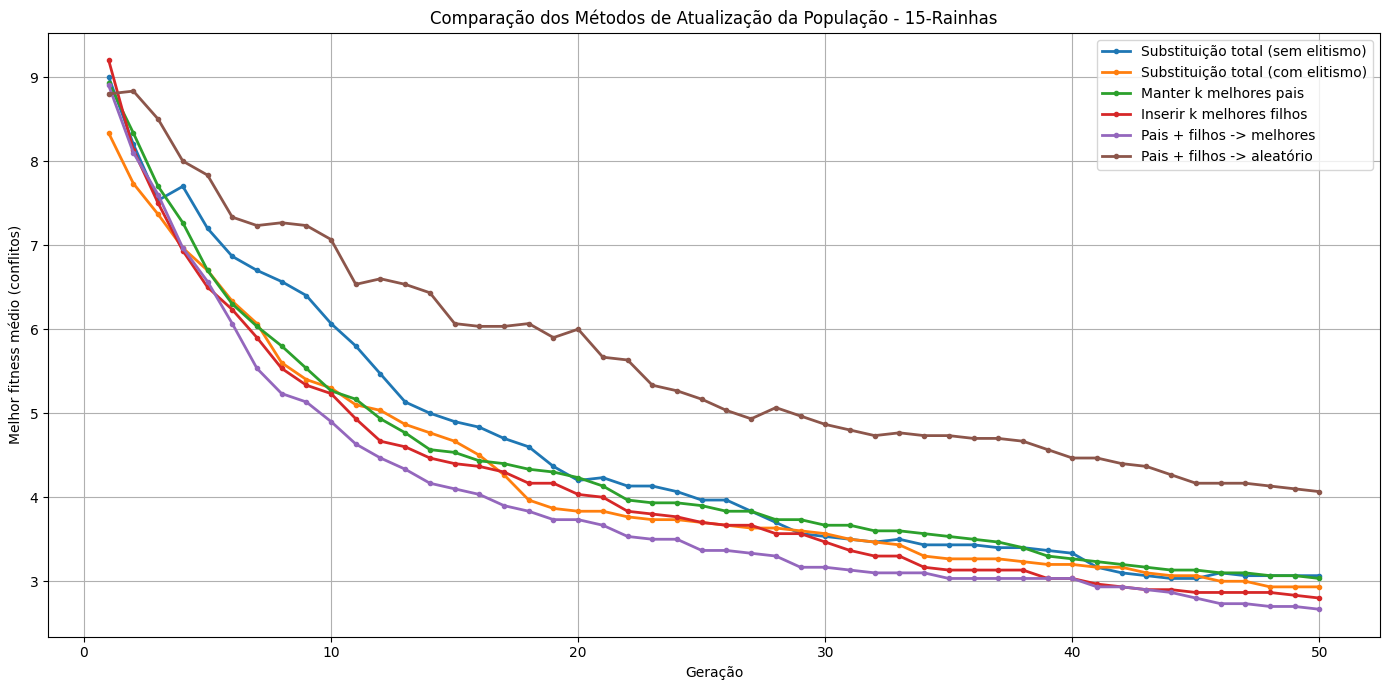

In [5]:
num_execucoes = 30
metodos = [
    "sem_elitismo",
    "com_elitismo",
    "k_melhores_pais",
    "k_melhores_filhos",
    "pais_filhos_melhores",
    "pais_filhos_aleatoria"
]

nomes_metodos = {
    "sem_elitismo": "Substituição total (sem elitismo)",
    "com_elitismo": "Substituição total (com elitismo)",
    "k_melhores_pais": "Manter k melhores pais",
    "k_melhores_filhos": "Inserir k melhores filhos",
    "pais_filhos_melhores": "Pais + filhos -> melhores",
    "pais_filhos_aleatoria": "Pais + filhos -> aleatório"
}

n = 15
m = 50
geracoes = 50
taxa_mutacao = 0.05
k = 15

# guarda resultados por método
resultados_por_metodo = {}

for metodo_escolhido in metodos:
    print(f"\nExecutando método: {nomes_metodos[metodo_escolhido]}")
    
    resultados_execucoes = []

    for execucao in range(num_execucoes):
        resultado = executar_alternativa3(
            m=m,
            n=n,
            geracoes=geracoes,
            taxa_mutacao=taxa_mutacao,
            metodo=metodo_escolhido,
            k=k
        )
        resultados_execucoes.append(resultado)

    tempos = [r["tempo_execucao"] for r in resultados_execucoes]
    geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
    melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]
    sucessos = [1 if r["melhor_conflito_global"] == 0 else 0 for r in resultados_execucoes]

    tempo_medio = np.mean(tempos)
    geracoes_medias = np.mean(geracoes_conv)
    melhor_fitness_medio = np.mean(melhores_finais)
    taxa_sucesso = np.mean(sucessos) * 100

    print("===== TABELA RESUMO =================================")
    print(f"Método: {nomes_metodos[metodo_escolhido]}")
    print(f"n = {n}")
    print(f"Tempo médio de execução: {tempo_medio:.4f} s")
    print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
    print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")
    print(f"Taxa de sucesso: {taxa_sucesso:.2f}%")
    print("=====================================================\n")

    historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
    historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

    media_historico_media = np.mean(historicos_media, axis=0)
    media_historico_melhor = np.mean(historicos_melhor, axis=0)

    resultados_por_metodo[metodo_escolhido] = {
        "tempo_medio": tempo_medio,
        "geracoes_medias": geracoes_medias,
        "melhor_fitness_medio": melhor_fitness_medio,
        "taxa_sucesso": taxa_sucesso,
        "media_historico_media": media_historico_media,
        "media_historico_melhor": media_historico_melhor
    }

print("\nTodas as execuções concluídas.")

# ---------- GRÁFICO --------------------------------------------------

plt.figure(figsize=(14, 7))

for metodo in metodos:
    plt.plot(
        range(1, geracoes + 1),
        resultados_por_metodo[metodo]["media_historico_melhor"],
        marker='o',
        markersize=3,
        linewidth=2,
        label=nomes_metodos[metodo]
    )

plt.xlabel("Geração")
plt.ylabel("Melhor fitness médio (conflitos)")
plt.title(f"Comparação dos Métodos de Atualização da População - {n}-Rainhas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Execução para 50 indivíduos, 20 rainhas, 50 gerações


Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 20
Tempo médio de execução: 0.3035 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 4.97
Taxa de sucesso: 0.00%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 20
Tempo médio de execução: 0.8624 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 4.50
Taxa de sucesso: 0.00%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 20
Tempo médio de execução: 0.5748 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 5.30
Taxa de sucesso: 0.00%


Executando método: Inserir k melhores filhos
===== TABELA RESUMO =================================
Método: Inserir 

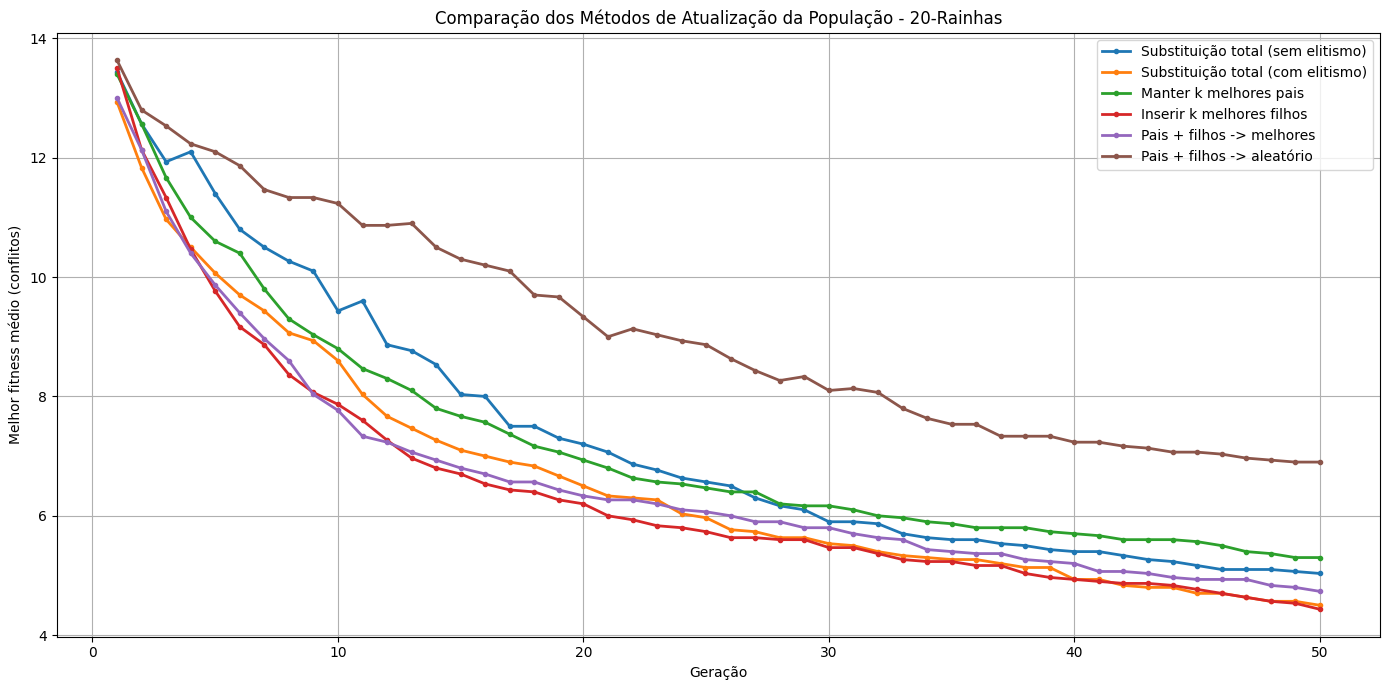

In [6]:
num_execucoes = 30
metodos = [
    "sem_elitismo",
    "com_elitismo",
    "k_melhores_pais",
    "k_melhores_filhos",
    "pais_filhos_melhores",
    "pais_filhos_aleatoria"
]

nomes_metodos = {
    "sem_elitismo": "Substituição total (sem elitismo)",
    "com_elitismo": "Substituição total (com elitismo)",
    "k_melhores_pais": "Manter k melhores pais",
    "k_melhores_filhos": "Inserir k melhores filhos",
    "pais_filhos_melhores": "Pais + filhos -> melhores",
    "pais_filhos_aleatoria": "Pais + filhos -> aleatório"
}

n = 20
m = 50
geracoes = 50
taxa_mutacao = 0.05
k = 15

# guarda resultados por método
resultados_por_metodo = {}

for metodo_escolhido in metodos:
    print(f"\nExecutando método: {nomes_metodos[metodo_escolhido]}")
    
    resultados_execucoes = []

    for execucao in range(num_execucoes):
        resultado = executar_alternativa3(
            m=m,
            n=n,
            geracoes=geracoes,
            taxa_mutacao=taxa_mutacao,
            metodo=metodo_escolhido,
            k=k
        )
        resultados_execucoes.append(resultado)

    tempos = [r["tempo_execucao"] for r in resultados_execucoes]
    geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
    melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]
    sucessos = [1 if r["melhor_conflito_global"] == 0 else 0 for r in resultados_execucoes]

    tempo_medio = np.mean(tempos)
    geracoes_medias = np.mean(geracoes_conv)
    melhor_fitness_medio = np.mean(melhores_finais)
    taxa_sucesso = np.mean(sucessos) * 100

    print("===== TABELA RESUMO =================================")
    print(f"Método: {nomes_metodos[metodo_escolhido]}")
    print(f"n = {n}")
    print(f"Tempo médio de execução: {tempo_medio:.4f} s")
    print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
    print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")
    print(f"Taxa de sucesso: {taxa_sucesso:.2f}%")
    print("=====================================================\n")

    historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
    historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

    media_historico_media = np.mean(historicos_media, axis=0)
    media_historico_melhor = np.mean(historicos_melhor, axis=0)

    resultados_por_metodo[metodo_escolhido] = {
        "tempo_medio": tempo_medio,
        "geracoes_medias": geracoes_medias,
        "melhor_fitness_medio": melhor_fitness_medio,
        "taxa_sucesso": taxa_sucesso,
        "media_historico_media": media_historico_media,
        "media_historico_melhor": media_historico_melhor
    }

print("\nTodas as execuções concluídas.")

# ---------- GRÁFICO --------------------------------------------------

plt.figure(figsize=(14, 7))

for metodo in metodos:
    plt.plot(
        range(1, geracoes + 1),
        resultados_por_metodo[metodo]["media_historico_melhor"],
        marker='o',
        markersize=3,
        linewidth=2,
        label=nomes_metodos[metodo]
    )

plt.xlabel("Geração")
plt.ylabel("Melhor fitness médio (conflitos)")
plt.title(f"Comparação dos Métodos de Atualização da População - {n}-Rainhas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Execução para 50 indivíduos, 30 rainhas, 50 gerações


Executando método: Substituição total (sem elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (sem elitismo)
n = 30
Tempo médio de execução: 0.6634 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 9.97
Taxa de sucesso: 0.00%


Executando método: Substituição total (com elitismo)
===== TABELA RESUMO =================================
Método: Substituição total (com elitismo)
n = 30
Tempo médio de execução: 1.9007 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 8.97
Taxa de sucesso: 0.00%


Executando método: Manter k melhores pais
===== TABELA RESUMO =================================
Método: Manter k melhores pais
n = 30
Tempo médio de execução: 1.2872 s
Número médio de gerações até convergência: 50.00
Melhor fitness médio encontrado: 10.60
Taxa de sucesso: 0.00%


Executando método: Inserir k melhores filhos
===== TABELA RESUMO =================================
Método: Inserir

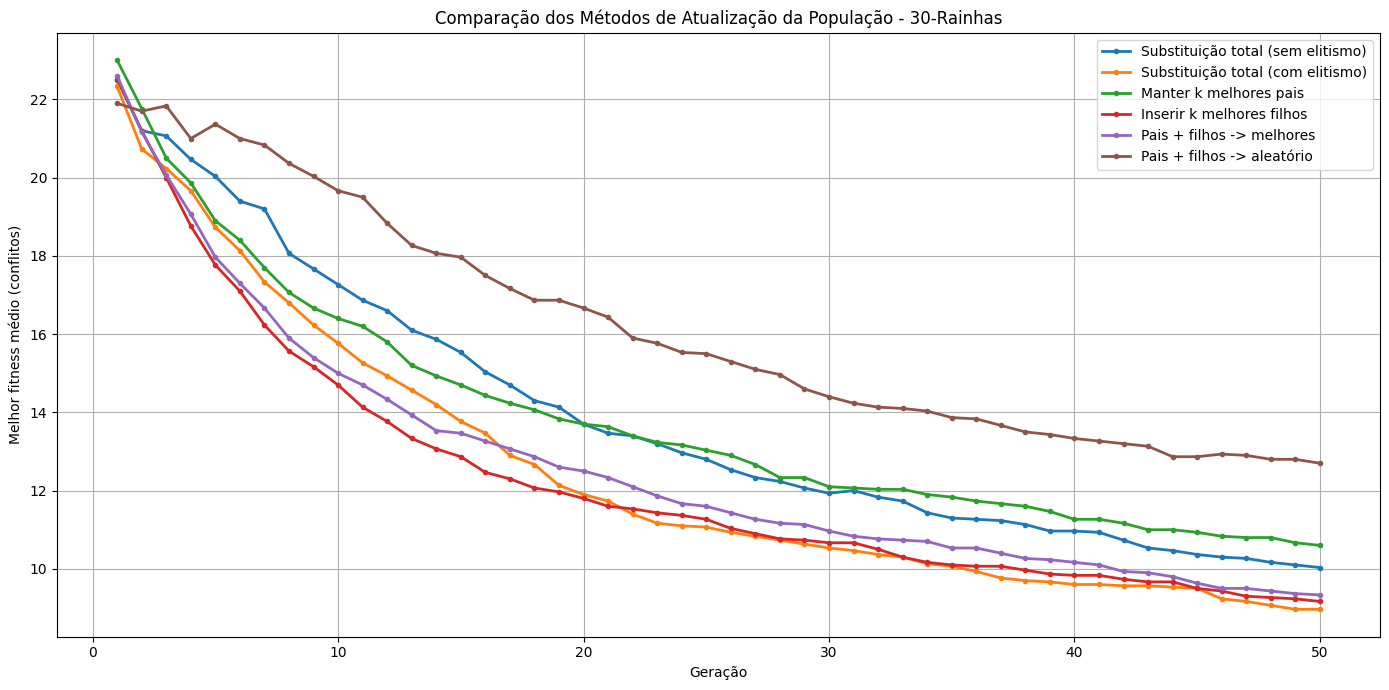

In [7]:
num_execucoes = 30
metodos = [
    "sem_elitismo",
    "com_elitismo",
    "k_melhores_pais",
    "k_melhores_filhos",
    "pais_filhos_melhores",
    "pais_filhos_aleatoria"
]

nomes_metodos = {
    "sem_elitismo": "Substituição total (sem elitismo)",
    "com_elitismo": "Substituição total (com elitismo)",
    "k_melhores_pais": "Manter k melhores pais",
    "k_melhores_filhos": "Inserir k melhores filhos",
    "pais_filhos_melhores": "Pais + filhos -> melhores",
    "pais_filhos_aleatoria": "Pais + filhos -> aleatório"
}

n = 30
m = 50
geracoes = 50
taxa_mutacao = 0.05
k = 15

# guarda resultados por método
resultados_por_metodo = {}

for metodo_escolhido in metodos:
    print(f"\nExecutando método: {nomes_metodos[metodo_escolhido]}")
    
    resultados_execucoes = []

    for execucao in range(num_execucoes):
        resultado = executar_alternativa3(
            m=m,
            n=n,
            geracoes=geracoes,
            taxa_mutacao=taxa_mutacao,
            metodo=metodo_escolhido,
            k=k
        )
        resultados_execucoes.append(resultado)

    tempos = [r["tempo_execucao"] for r in resultados_execucoes]
    geracoes_conv = [r["geracao_convergencia"] for r in resultados_execucoes]
    melhores_finais = [r["melhor_conflito_global"] for r in resultados_execucoes]
    sucessos = [1 if r["melhor_conflito_global"] == 0 else 0 for r in resultados_execucoes]

    tempo_medio = np.mean(tempos)
    geracoes_medias = np.mean(geracoes_conv)
    melhor_fitness_medio = np.mean(melhores_finais)
    taxa_sucesso = np.mean(sucessos) * 100

    print("===== TABELA RESUMO =================================")
    print(f"Método: {nomes_metodos[metodo_escolhido]}")
    print(f"n = {n}")
    print(f"Tempo médio de execução: {tempo_medio:.4f} s")
    print(f"Número médio de gerações até convergência: {geracoes_medias:.2f}")
    print(f"Melhor fitness médio encontrado: {melhor_fitness_medio:.2f}")
    print(f"Taxa de sucesso: {taxa_sucesso:.2f}%")
    print("=====================================================\n")

    historicos_media = np.array([r["historico_media"] for r in resultados_execucoes])
    historicos_melhor = np.array([r["historico_melhor"] for r in resultados_execucoes])

    media_historico_media = np.mean(historicos_media, axis=0)
    media_historico_melhor = np.mean(historicos_melhor, axis=0)

    resultados_por_metodo[metodo_escolhido] = {
        "tempo_medio": tempo_medio,
        "geracoes_medias": geracoes_medias,
        "melhor_fitness_medio": melhor_fitness_medio,
        "taxa_sucesso": taxa_sucesso,
        "media_historico_media": media_historico_media,
        "media_historico_melhor": media_historico_melhor
    }

print("\nTodas as execuções concluídas.")

# ---------- GRÁFICO --------------------------------------------------

plt.figure(figsize=(14, 7))

for metodo in metodos:
    plt.plot(
        range(1, geracoes + 1),
        resultados_por_metodo[metodo]["media_historico_melhor"],
        marker='o',
        markersize=3,
        linewidth=2,
        label=nomes_metodos[metodo]
    )

plt.xlabel("Geração")
plt.ylabel("Melhor fitness médio (conflitos)")
plt.title(f"Comparação dos Métodos de Atualização da População - {n}-Rainhas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()